In [2]:
from google.colab import files
uploaded = files.upload()

Saving Book1.xlsx to Book1 (1).xlsx


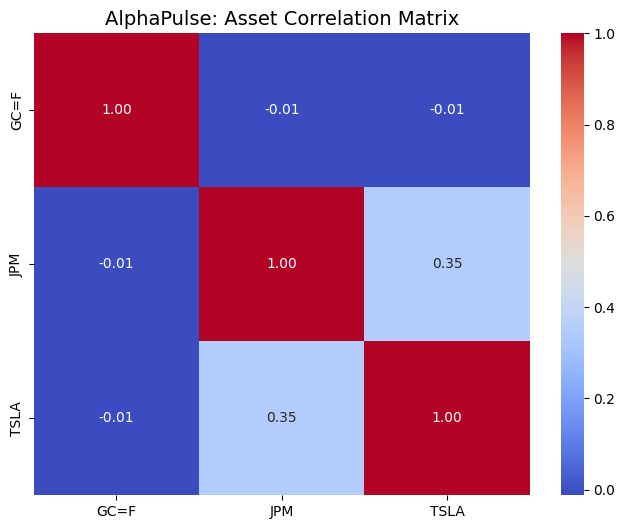

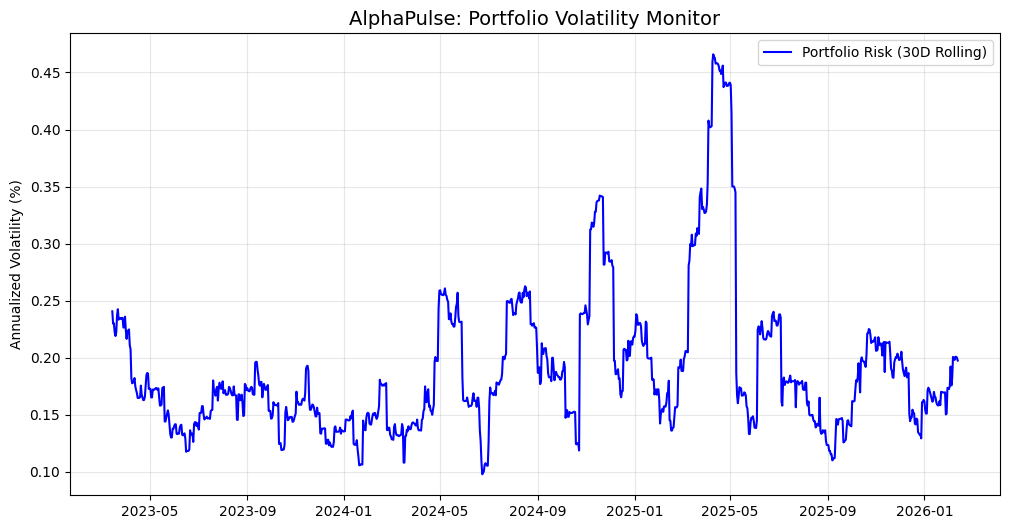

Success! Processed data saved for Week 3 (Tableau).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('Book1.xlsx', index_col=0)
df.index = pd.to_datetime(df.index)



assets = ['GC=F', 'JPM', 'TSLA']
df_portfolio = df[assets].ffill()


returns = np.log(df_portfolio / df_portfolio.shift(1)).dropna()


plt.figure(figsize=(8, 6))
correlation_matrix = returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('AlphaPulse: Asset Correlation Matrix', fontsize=14)
plt.show()


weights = np.array([1/len(assets)] * len(assets)) # 33.3% each
portfolio_returns = returns.dot(weights)
rolling_vol = portfolio_returns.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))
plt.plot(rolling_vol, color='blue', label='Portfolio Risk (30D Rolling)')
plt.title('AlphaPulse: Portfolio Volatility Monitor', fontsize=14)
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


returns.to_csv("AlphaPulse_Portfolio_Returns.csv")
print("Success! Processed data saved for Week 3 (Tableau).")

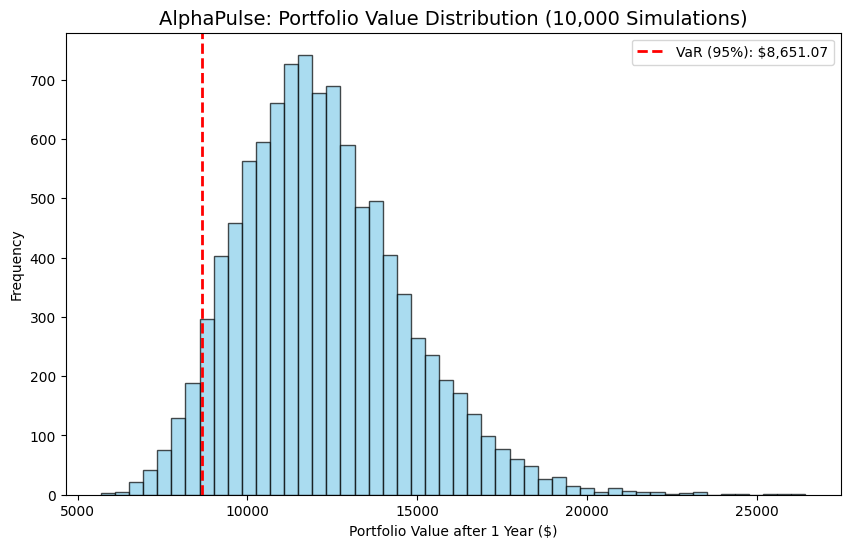

--- RISK SUMMARY ---
Initial Investment: $10000
95% Value at Risk (VaR): $1,348.93
This means there is a 5% chance your portfolio could lose more than $1,348.93 in a year.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


initial_investment = 10000
num_simulations = 10000
time_horizon = 252 # 1 Year (Trading Days)



mean_returns = returns.mean()
cov_matrix = returns.cov()

# Weights: Equal distribution (33.3% each)
weights = np.array([1/3, 1/3, 1/3])

# --- 2. MONTE CARLO CORE (VECTORIZED) ---
# Create a matrix to store results
simulation_results = np.zeros((time_horizon, num_simulations))

# Pre-calculate Portfolio Mean and Std Dev for efficiency
portfolio_mean = np.sum(mean_returns * weights)
portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

# Generate 10,000 random scenarios
for i in range(num_simulations):
    # Random daily returns based on normal distribution
    daily_returns = np.random.normal(portfolio_mean, portfolio_std, time_horizon)
    # Calculate price path: Price_t = Price_0 * (1 + return)^t
    simulation_results[:, i] = initial_investment * np.cumprod(1 + daily_returns)


final_values = simulation_results[-1, :]
# 5th Percentile represents 95% Confidence Interval
var_95 = np.percentile(final_values, 5)
potential_loss = initial_investment - var_95

# --- 4. VISUALIZE THE RISK DISTRIBUTION ---
plt.figure(figsize=(10, 6))
plt.hist(final_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(var_95, color='red', linestyle='dashed', linewidth=2, label=f'VaR (95%): ${var_95:,.2f}')
plt.title('AlphaPulse: Portfolio Value Distribution (10,000 Simulations)', fontsize=14)
plt.xlabel('Portfolio Value after 1 Year ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"--- RISK SUMMARY ---")
print(f"Initial Investment: ${initial_investment}")
print(f"95% Value at Risk (VaR): ${potential_loss:,.2f}")
print(f"This means there is a 5% chance your portfolio could lose more than ${potential_loss:,.2f} in a year.")

In [8]:


df_history = returns.copy()
df_history['Portfolio_Rolling_Vol'] = rolling_vol
df_history.to_csv("AlphaPulse_Historical_Trends.csv")



sim_df = pd.DataFrame(final_values, columns=['Final_Portfolio_Value'])
sim_df.to_csv("AlphaPulse_Simulation_Outcomes.csv")

print("Files ready for Tableau: \n1. AlphaPulse_Historical_Trends.csv \n2. AlphaPulse_Simulation_Outcomes.csv")

Files ready for Tableau: 
1. AlphaPulse_Historical_Trends.csv 
2. AlphaPulse_Simulation_Outcomes.csv


In [9]:


risk_free_rate = 0.04 # Assume 4% (Standard for US Treasury/FD)


portfolio_return_annual = np.sum(returns.mean() * weights) * 252

portfolio_vol_annual = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))


sharpe_ratio = (portfolio_return_annual - risk_free_rate) / portfolio_vol_annual

print(f"--- Executive Summary Metrics ---")
print(f"Expected Annual Return: {portfolio_return_annual:.2%}")
print(f"Annual Risk (Volatility): {portfolio_vol_annual:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")


summary_data = {
    'Metric': ['Annual Return', 'Annual Volatility', 'Sharpe Ratio', '95% VaR'],
    'Value': [portfolio_return_annual, portfolio_vol_annual, sharpe_ratio, potential_loss]
}
pd.DataFrame(summary_data).to_csv("AlphaPulse_KPI_Summary.csv")

--- Executive Summary Metrics ---
Expected Annual Return: 20.01%
Annual Risk (Volatility): 1.26%
Sharpe Ratio: 12.72


In [10]:

historical_portfolio_returns = returns.dot(weights)

initial_investment = 10000
historical_dollar_losses = historical_portfolio_returns * initial_investment

daily_var_95 = np.percentile(historical_dollar_losses, 5)

exceedances = historical_dollar_losses[historical_dollar_losses < daily_var_95]
num_exceedances = len(exceedances)
total_days = len(historical_dollar_losses)
violation_rate = (num_exceedances / total_days) * 100

print(f"--- Backtesting Results ---")
print(f"Total Trading Days: {total_days}")
print(f"Daily 95% VaR: ${abs(daily_var_95):,.2f}")
print(f"Number of times loss exceeded VaR: {num_exceedances}")
print(f"Violation Rate: {violation_rate:.2f}%")


if violation_rate <= 5.0:
    print("Result: Model is Robust (Accurate).")
else:
    print("Result: Model is Aggressive (Needs adjustment).")

--- Backtesting Results ---
Total Trading Days: 1095
Daily 95% VaR: $184.13
Number of times loss exceeded VaR: 55
Violation Rate: 5.02%
Result: Model is Aggressive (Needs adjustment).
